In [1]:
#!pip install pandas


In [5]:
pip install pandas


  Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl (11.5 MB)
Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl (12.6 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [numpy]
   -------------------- ------------------- 2/4 [numpy]
   -------------------- ------------------- 2/4 [numpy]
   -------------------- -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK data (only needed once)
nltk.download('stopwords')
nltk.download('wordnet')

# Load data
metadata = pd.read_csv('movie.metadata.tsv', sep='\t', header=None)
summaries = pd.read_csv('plot_summaries.txt', sep='\t', header=None)

# Initialize NLP components
stopwords_set = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Optimized cleaning function
def clean_text_optimized(text):
    text = str(text).lower()  # Ensure text is string
    text = re.sub(r'[^\w\s]|\d+', '', text)  # Combined regex
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word not in stopwords_set]
    return ' '.join(tokens)

# Apply cleaning
summaries['cleaned_summary'] = summaries[1].apply(clean_text_optimized)

ModuleNotFoundError: No module named 'pandas'

In [9]:
from ast import literal_eval

# Extract genres from metadata
metadata['genres'] = metadata[8].apply(literal_eval).apply(lambda x: list(x.values()))

# Merge data
merged_data = pd.merge(summaries, metadata, on=0)
final_data = merged_data[[0, 'cleaned_summary', 'genres']]
final_data.columns = ['movie_id', 'summary', 'genres']

# Save cleaned data
final_data.to_csv('cleaned_movie_data.csv', index=False)

In [10]:
from sklearn.model_selection import train_test_split

X = final_data['summary']
y = final_data['genres']

# Multi-label binarization
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binarized, test_size=0.2, random_state=42)

In [12]:
!pip install googletrans==4.0.0-rc1


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: C:\Users\FAHAD\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [23]:
!pip install deep-translator


Defaulting to user installation because normal site-packages is not writeable


In [14]:
from deep_translator import GoogleTranslator

def translate_text(text, target_lang):
    return GoogleTranslator(source='auto', target=target_lang).translate(text)

# Example usage
summary = "A group of friends embark on an adventure"
arabic_translation = translate_text(summary, 'ar')
urdu_translation = translate_text(summary, 'ur')
korean_translation = translate_text(summary, 'ko')

print("Arabic:", arabic_translation)
print("Urdu:", urdu_translation)
print("Korean:", korean_translation)


Arabic: مجموعة من الأصدقاء يشرعون في مغامرة
Urdu: دوستوں کا ایک گروپ ایک مہم جوئی کا آغاز کرتا ہے
Korean: 친구 그룹이 모험을 시작합니다


In [15]:
from deep_translator import GoogleTranslator
from gtts import gTTS
import os

# Function to translate text
def translate_text(text, target_lang):
    return GoogleTranslator(source='auto', target=target_lang).translate(text)

# Function to convert text to speech
def text_to_speech(text, lang, filename):
    try:
        tts = gTTS(text=text, lang=lang)
        tts.save(filename)
        print(f"Audio saved as {filename}")
    except Exception as e:
        print(f"Failed to generate speech for {lang}: {e}")

# Input summary
summary = "A group of friends embark on an adventure"

# Translations
arabic_translation = translate_text(summary, 'ar')
urdu_translation = translate_text(summary, 'ur')
korean_translation = translate_text(summary, 'ko')

# Output the translated text (optional)
print("Arabic Translation:", arabic_translation)
print("Urdu Translation:", urdu_translation)
print("Korean Translation:", korean_translation)

# Convert to speech
text_to_speech(arabic_translation, 'ar', 'arabic_summary.mp3')
text_to_speech(urdu_translation, 'ur', 'urdu_summary.mp3')
text_to_speech(korean_translation, 'ko', 'korean_summary.mp3')


Arabic Translation: مجموعة من الأصدقاء يشرعون في مغامرة
Urdu Translation: دوستوں کا ایک گروپ ایک مہم جوئی کا آغاز کرتا ہے
Korean Translation: 친구 그룹이 모험을 시작합니다
Audio saved as arabic_summary.mp3
Audio saved as urdu_summary.mp3
Audio saved as korean_summary.mp3


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [17]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import f1_score

# Model training
model = OneVsRestClassifier(LogisticRegression())
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

print("F1 (micro):", f1_score(y_test, y_pred, average='micro'))
print("F1 (macro):", f1_score(y_test, y_pred, average='macro'))

C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 48 is present in all training examples.
  warnings.warn(
C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 52 is present in all training examples.
  warnings.warn(
C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 61 is present in all training examples.
  warnings.warn(
C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 66 is present in all training examples.
  warnings.warn(
C:\Users\FAHAD\AppDa

Accuracy: 0.07084468664850137
                                          precision    recall  f1-score   support

                               Absurdism       0.00      0.00      0.00        12
                            Acid western       0.00      0.00      0.00         1
                                  Action       0.65      0.28      0.39      1164
                           Action Comedy       0.00      0.00      0.00        25
                        Action Thrillers       0.00      0.00      0.00        83
                        Action/Adventure       0.60      0.16      0.26       695
                         Addiction Drama       0.00      0.00      0.00         7
                                   Adult       0.00      0.00      0.00        27
                               Adventure       0.69      0.17      0.27       660
                        Adventure Comedy       0.00      0.00      0.00        22
                  Airplanes and airports       0.00      0.00      

C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:15

F1 (micro): 0.3206911403308758
F1 (macro): 0.030309923933060073


C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
!pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: C:\Users\FAHAD\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\FAHAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:15

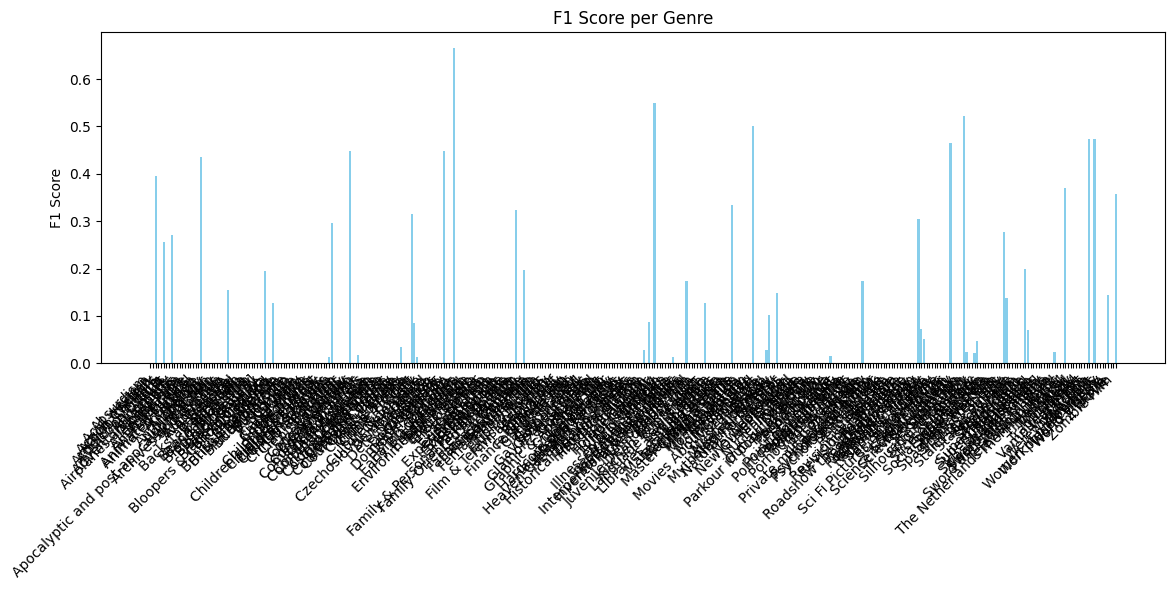

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Get F1 scores for each genre
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

genres = mlb.classes_

# Bar chart
plt.figure(figsize=(12, 6))
plt.bar(genres, f1, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1 Score')
plt.title('F1 Score per Genre')
plt.tight_layout()
plt.show()

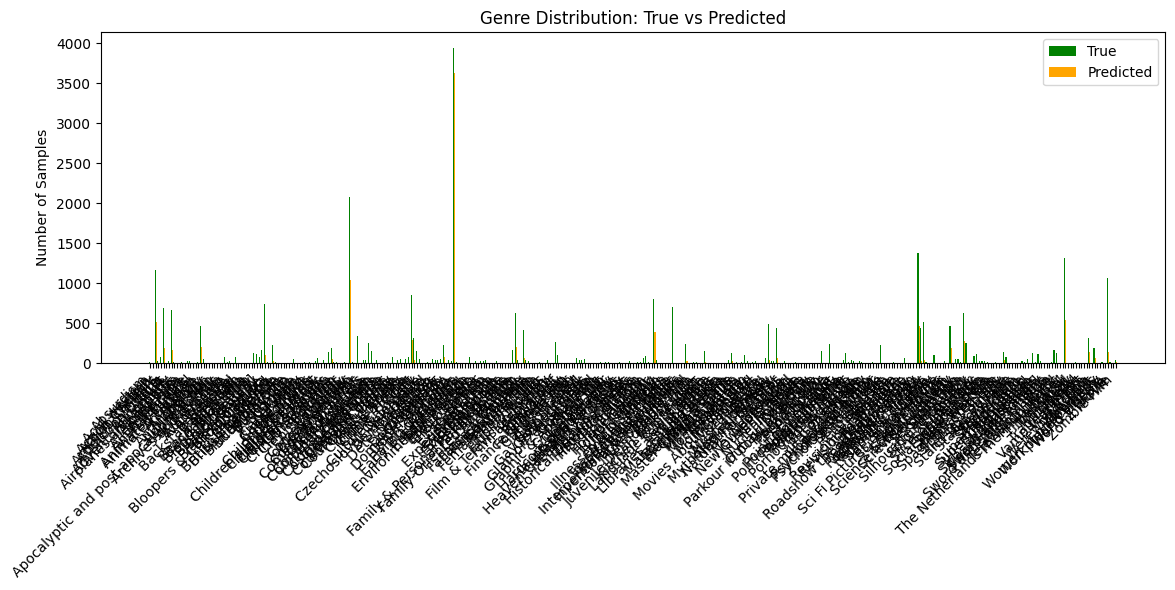

In [20]:
# Sum of true and predicted genres per label
true_counts = y_test.sum(axis=0)
pred_counts = y_pred.sum(axis=0)

x = np.arange(len(genres))

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, true_counts, width=0.4, label='True', color='green')
plt.bar(x + 0.2, pred_counts, width=0.4, label='Predicted', color='orange')
plt.xticks(x, genres, rotation=45, ha='right')
plt.ylabel('Number of Samples')
plt.title('Genre Distribution: True vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()